In [16]:
#Using Libraries and Loading DataSet
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

plt.style.use('default')
sns.set_palette("husl")

df = pd.read_csv(r'C:\Users\Muhammad Taha\Desktop\vgchartz-2024.csv') 

In [17]:
# Data preprocessing
# Convert release_date to datetime and extract year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

In [18]:
# Clean the data - remove rows with missing critical scores or sales
df_clean = df.dropna(subset=['critic_score', 'total_sales']).copy()

In [19]:
# Filter out extreme outliers that might skew the trendline
df_clean = df_clean[df_clean['total_sales'] < 50]  # Remove games with sales > 50M

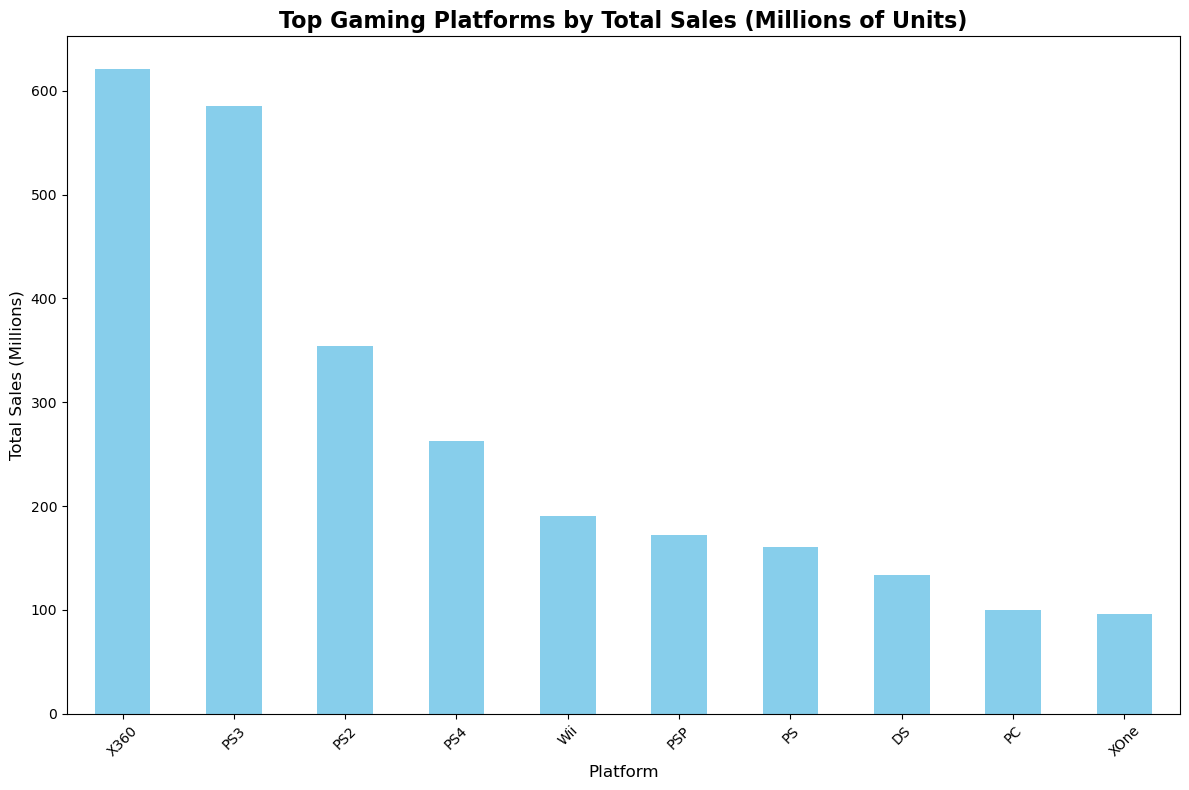

In [20]:
# 1. Platform Dominance - Top platforms by total sales
plt.figure(figsize=(12, 8))
platform_sales = df_clean.groupby('console')['total_sales'].sum().sort_values(ascending=False).head(10)
platform_sales.plot(kind='bar', color='skyblue')
plt.title('Top Gaming Platforms by Total Sales (Millions of Units)', fontsize=16, fontweight='bold')
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Total Sales (Millions)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

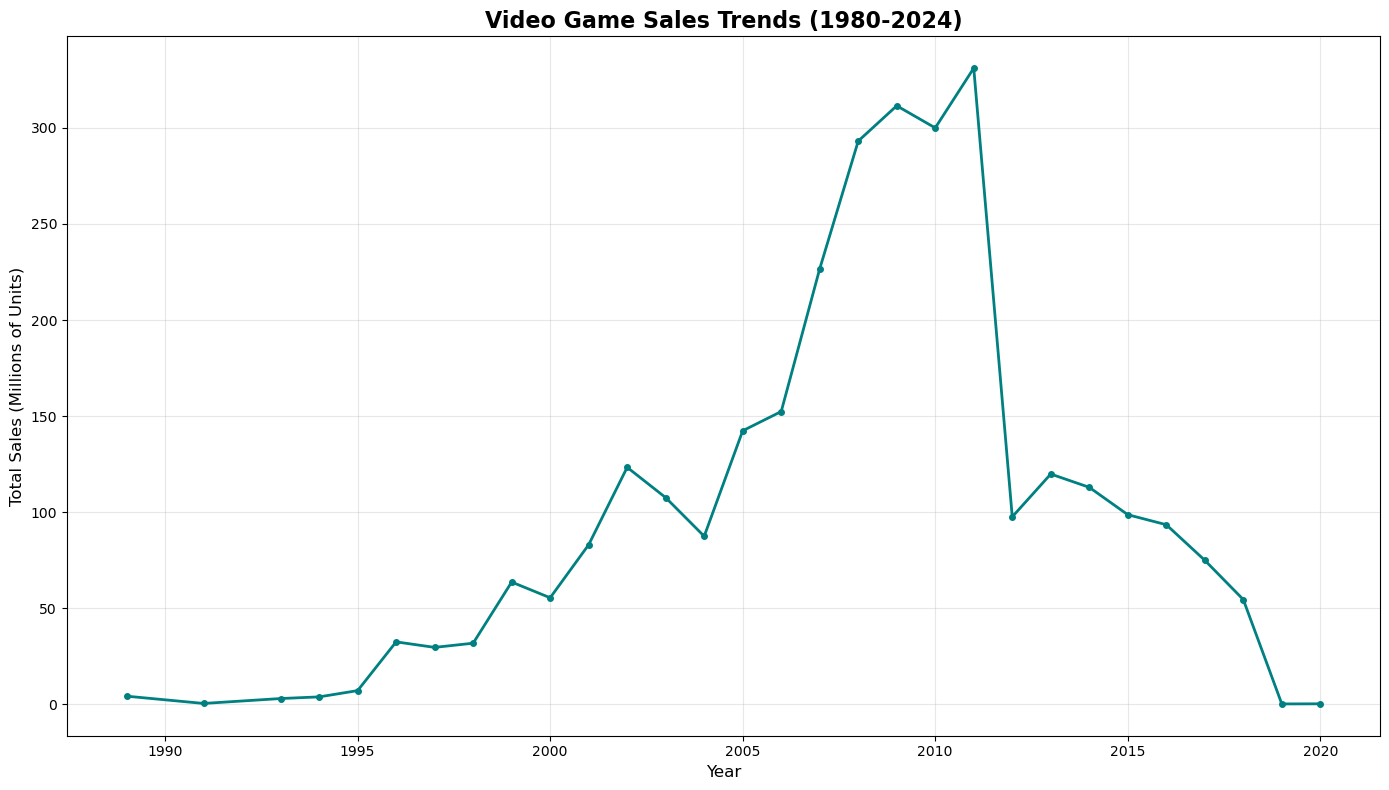

In [21]:
# 2. Sales Trends Over Time
plt.figure(figsize=(14, 8))
yearly_sales = df_clean.groupby('release_year')['total_sales'].sum()
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', linewidth=2, markersize=4, color='teal')
plt.title('Video Game Sales Trends (1980-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales (Millions of Units)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

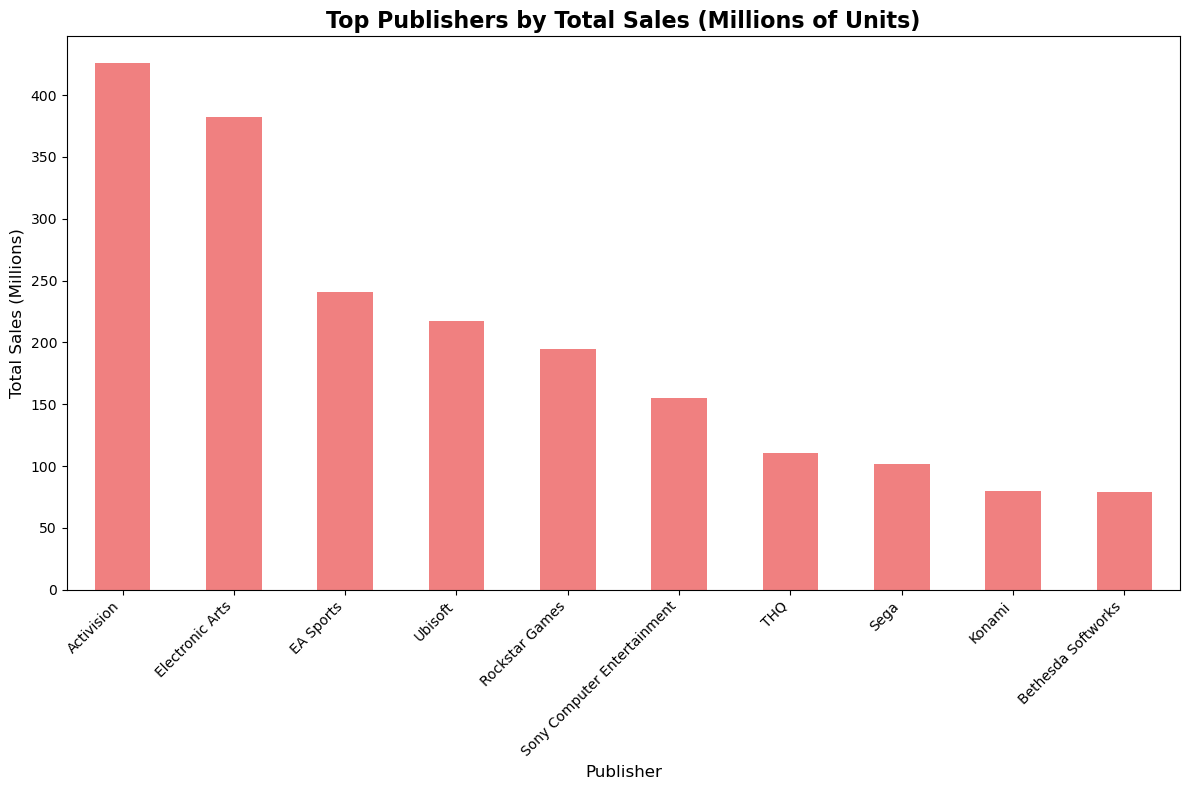

In [22]:
# 3. Top Publishers
plt.figure(figsize=(12, 8))
publisher_sales = df_clean.groupby('publisher')['total_sales'].sum().sort_values(ascending=False).head(10)
publisher_sales.plot(kind='bar', color='lightcoral')
plt.title('Top Publishers by Total Sales (Millions of Units)', fontsize=16, fontweight='bold')
plt.xlabel('Publisher', fontsize=12)
plt.ylabel('Total Sales (Millions)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

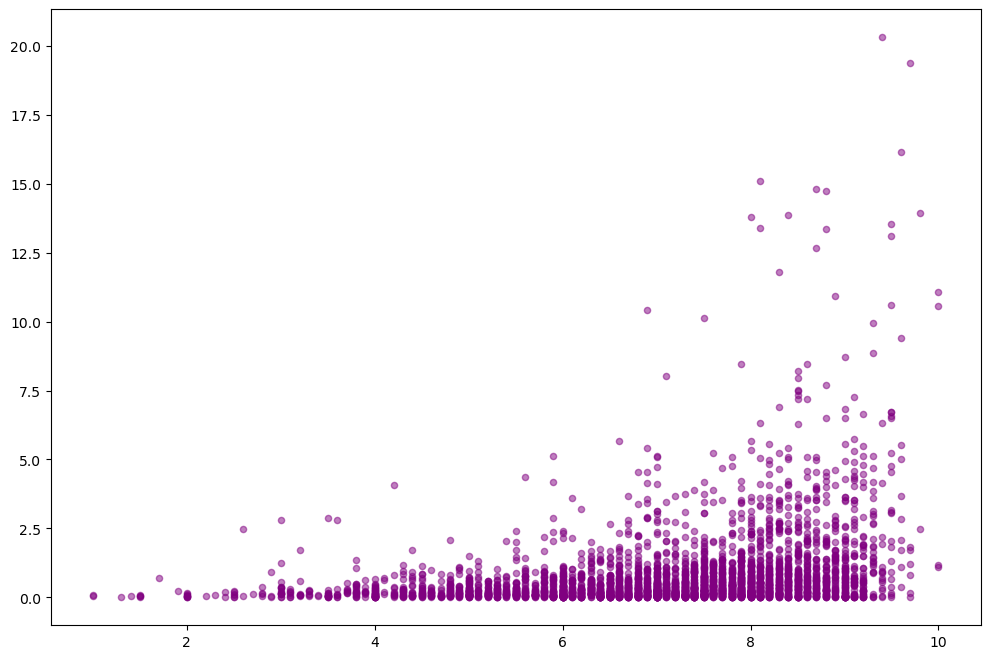

In [23]:
# 4. Critic Score vs Commercial Success (FIXED)
plt.figure(figsize=(12, 8))
plt.scatter(df_clean['critic_score'], df_clean['total_sales'], alpha=0.5, s=20, color='purple')

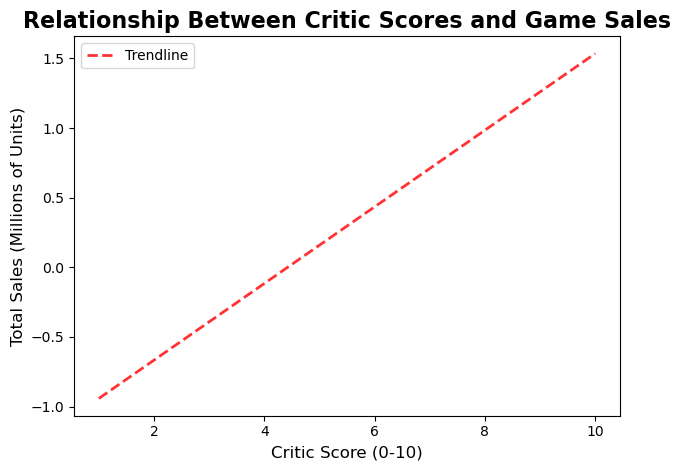

In [24]:
# Add trendline (FIXED VERSION)
try:
    # Filter out any remaining NaN values just to be safe
    valid_data = df_clean[['critic_score', 'total_sales']].dropna()
    if len(valid_data) > 1:  # Ensure we have enough data points
        z = np.polyfit(valid_data['critic_score'], valid_data['total_sales'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(valid_data['critic_score'].min(), valid_data['critic_score'].max(), 100)
        plt.plot(x_range, p(x_range), "r--", linewidth=2, alpha=0.8, label='Trendline')
        plt.legend()
except Exception as e:
    print(f"Could not create trendline: {e}")

plt.title('Relationship Between Critic Scores and Game Sales', fontsize=16, fontweight='bold')
plt.xlabel('Critic Score (0-10)', fontsize=12)
plt.ylabel('Total Sales (Millions of Units)', fontsize=12)
plt.tight_layout()
plt.show()

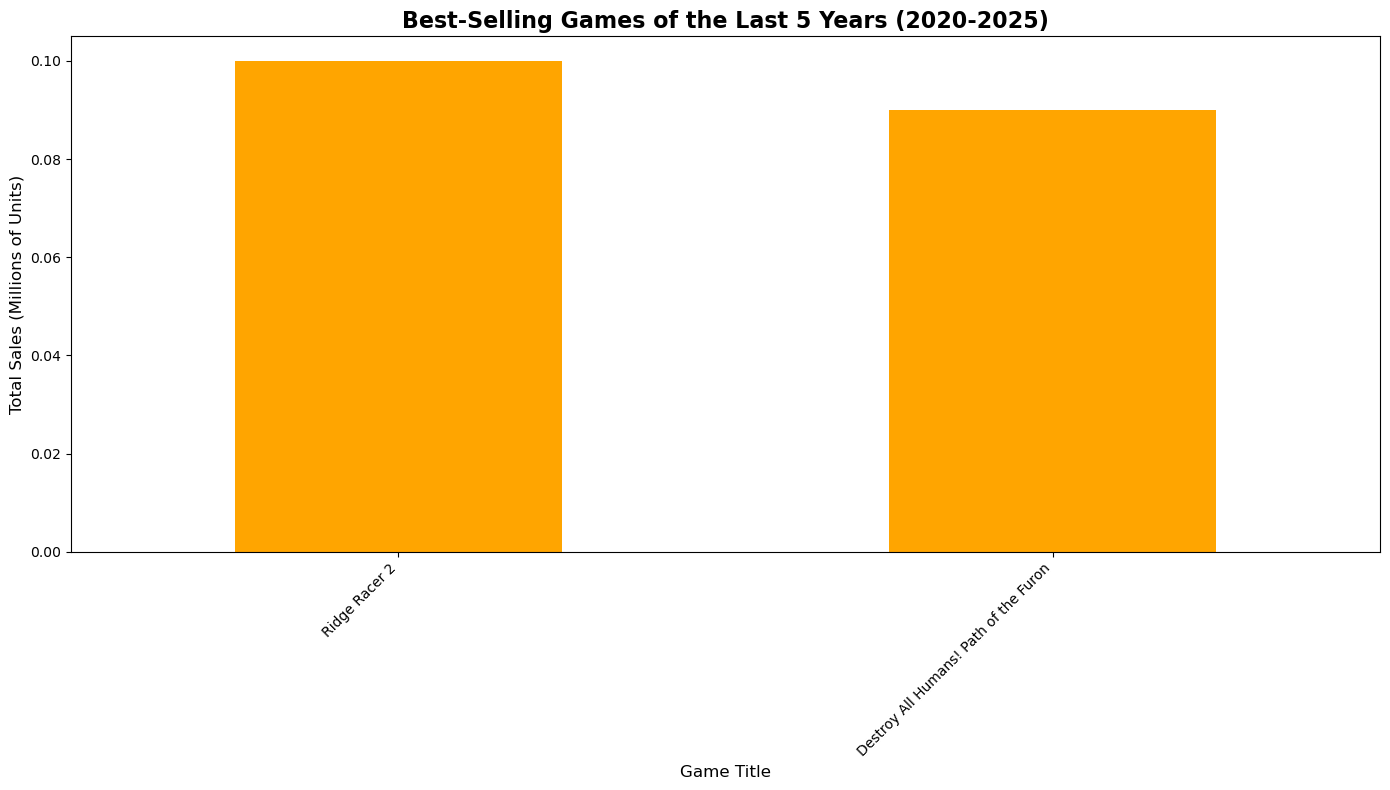

In [25]:
# 5. Best-Selling Games of Last 5 Years
current_year = datetime.now().year
last_5_years = df_clean[df_clean['release_year'] >= (current_year - 5)]

plt.figure(figsize=(14, 8))
top_recent_games = last_5_years.groupby('title')['total_sales'].sum().sort_values(ascending=False).head(10)
top_recent_games.plot(kind='bar', color='orange')
plt.title(f'Best-Selling Games of the Last 5 Years ({current_year-5}-{current_year})', fontsize=16, fontweight='bold')
plt.xlabel('Game Title', fontsize=12)
plt.ylabel('Total Sales (Millions of Units)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

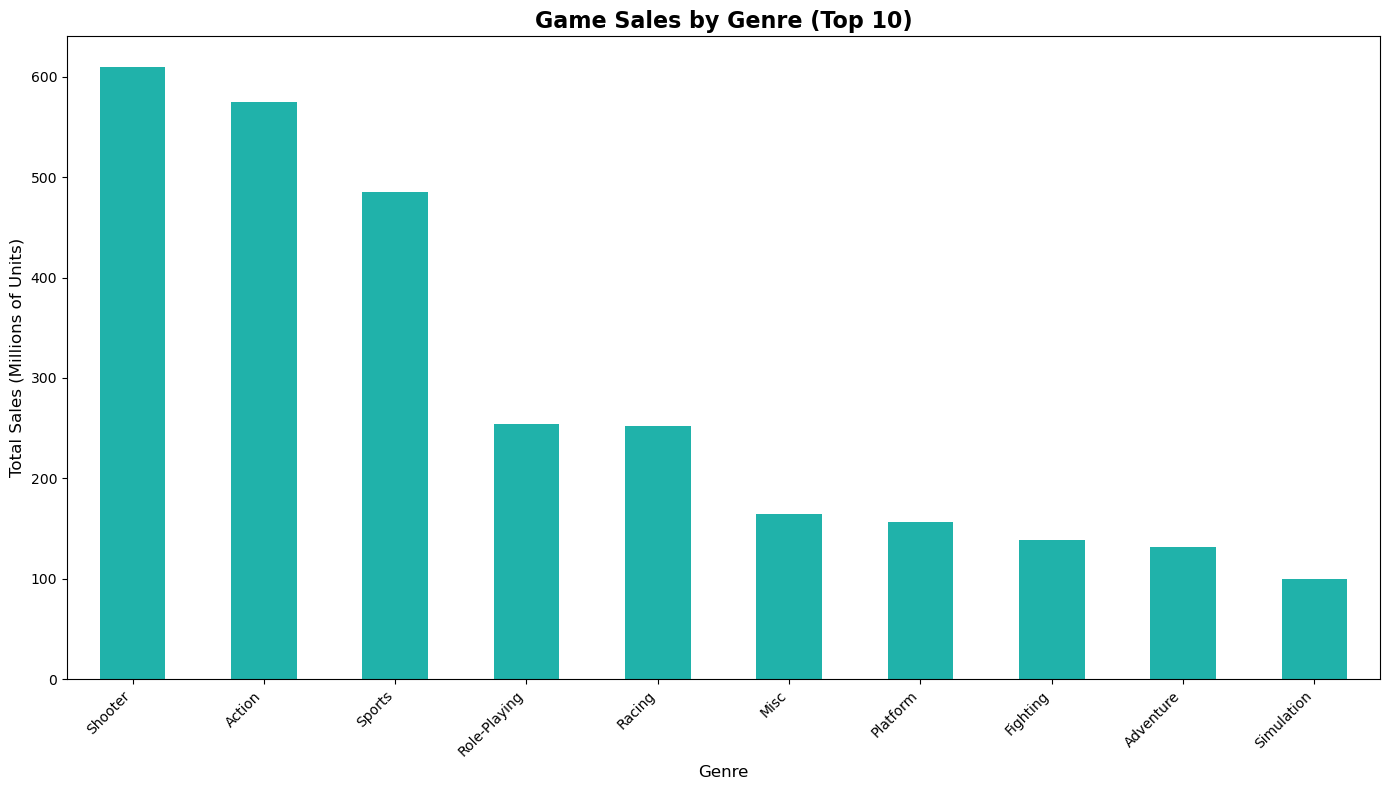

In [26]:
# 6. Genre popularity
plt.figure(figsize=(14, 8))
genre_sales = df_clean.groupby('genre')['total_sales'].sum().sort_values(ascending=False).head(10)
genre_sales.plot(kind='bar', color='lightseagreen')
plt.title('Game Sales by Genre (Top 10)', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Total Sales (Millions of Units)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

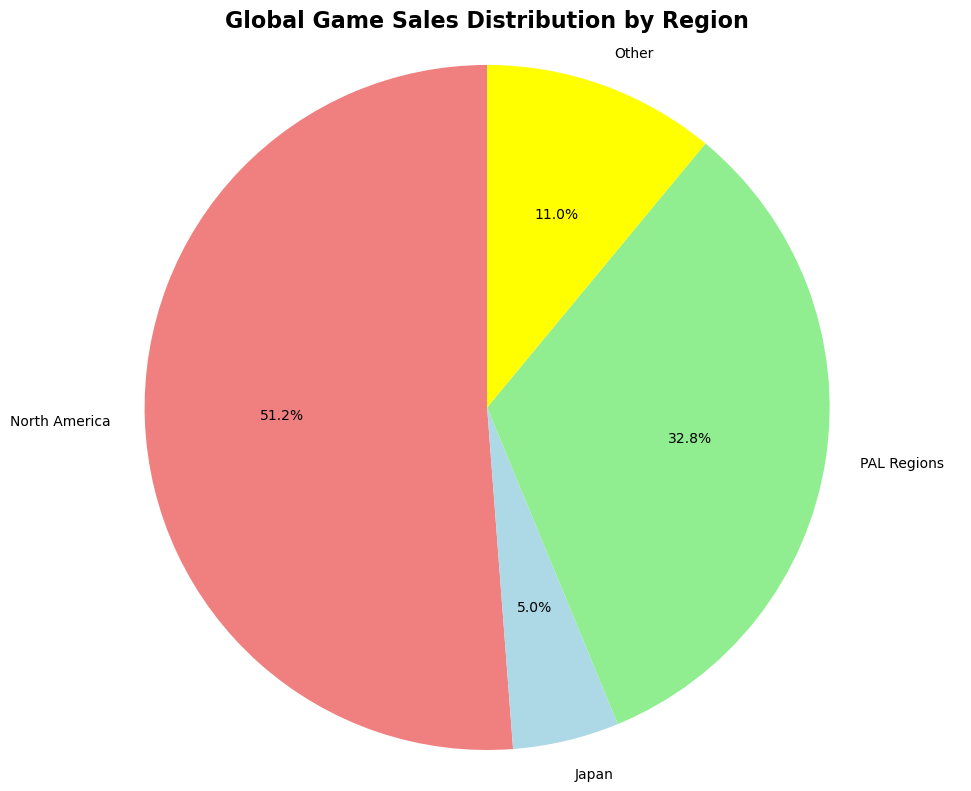

In [27]:
# 7. Regional Sales Analysis
regions = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
region_totals = df_clean[regions].sum()

plt.figure(figsize=(10, 8))
plt.pie(region_totals, labels=['North America', 'Japan', 'PAL Regions', 'Other'], 
        autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightblue', 'lightgreen', 'yellow'])
plt.title('Global Game Sales Distribution by Region', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [28]:
# Print some key statistics
print("KEY STATISTICS:")
print(f"Total games in dataset: {len(df)}")
print(f"Games after cleaning: {len(df_clean)}")
print(f"Average critic score: {df_clean['critic_score'].mean():.2f}")
print(f"Average sales per game: {df_clean['total_sales'].mean():.2f}M")
print(f"Highest selling game: {df_clean.loc[df_clean['total_sales'].idxmax(), 'title']} "
      f"({df_clean['total_sales'].max():.2f}M units)")

KEY STATISTICS:
Total games in dataset: 64016
Games after cleaning: 4126
Average critic score: 7.10
Average sales per game: 0.74M
Highest selling game: Grand Theft Auto V (20.32M units)
